In [48]:
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from presp.prescriptor import NNPrescriptor, NNPrescriptorFactory
import torch
import yaml

# from examples.constraints.context.utils import Experimenter

In [49]:
from constraints.constraint_prescriptor import ConstraintPrescriptor
from constraints.problems import BNH, Circle, Triangle

class Experimenter:
    def __init__(self, results_dir: Path):
        with open(results_dir / "config.yml", "r", encoding="utf-8") as f:
            self.config = yaml.safe_load(f)

        if self.config["problem"] == "triangle":
            self.evaluator = Triangle(**self.config["eval_params"])
            self.factory = NNPrescriptorFactory(ConstraintPrescriptor, **self.config["prescriptor_params"])
        elif self.config["problem"] == "circle":
            self.evaluator = Circle(**self.config["eval_params"])
            self.factory = NNPrescriptorFactory(NNPrescriptor, **self.config["prescriptor_params"])
        elif self.config["problem"] == "bnh":
            self.evaluator = BNH(**self.config["eval_params"])
            self.factory = NNPrescriptorFactory(ConstraintPrescriptor, **self.config["prescriptor_params"])
        else:
            raise ValueError("Problem not supported")
        
        self.population = self.factory.load_population(results_dir / "population")
        self.results_dir = results_dir

        self.results_df = pd.read_csv(self.results_dir / "results.csv")

    def get_gen_df(self, gen: int, pareto: bool = True) -> pd.DataFrame:
        gen_df = self.results_df[self.results_df["gen"] == gen]
        if pareto:
            gen_df = gen_df[gen_df["rank"] == 1]
        return gen_df

    def get_candidate_solutions(self, cand_id: str, contexts: torch.Tensor = None) -> torch.Tensor:
        candidate = self.population[cand_id]
        if contexts is None:
            contexts = self.evaluator.contexts
        actions, _, _ = self.evaluator.prescribe_and_predict(candidate, contexts)
        return actions.cpu().numpy()

    def compute_hypervolume_2d(self, pareto_front: np.ndarray, ref_point: np.ndarray, ideal: np.ndarray) -> float:
        """
        Assumes minimization.
        Pareto front is n x 2
        """
        hypervolume = 0
        pareto_front = np.sort(pareto_front, axis=0)
        for i in range(pareto_front.shape[0]):

            x1 = pareto_front[i, 0]
            if i == pareto_front.shape[0] - 1:
                x2 = ref_point[0]
            else:
                x2 = pareto_front[i+1, 0]

            y1 = pareto_front[i, 1]
            y2 = ref_point[1]

            volume = (x2 - x1) * (y2 - y1)
            volume = max(volume, 0)
            hypervolume += volume

        total_volume = (ref_point[0] - ideal[0]) * (ref_point[1] - ideal[1])
        hypervolume /= total_volume

        return hypervolume

In [50]:
RESULTS_DIR = Path("results/bnh")
with open(RESULTS_DIR / "config.yml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)
results_df = pd.read_csv(RESULTS_DIR / "results.csv")
GENS = results_df["gen"].max()

experimenter = Experimenter(RESULTS_DIR)

pprint(config)

{'eval_params': {'device': 'mps', 'n_jobs': -1},
 'evolution_params': {'mutation_factor': 0.1,
                      'mutation_rate': 0.1,
                      'n_elites': 0,
                      'n_generations': 100,
                      'population_size': 100,
                      'remove_population_pct': 0,
                      'save_path': 'results/bnh'},
 'prescriptor_params': {'device': 'mps',
                        'model_params': [{'in_features': 4,
                                          'out_features': 64,
                                          'type': 'linear'},
                                         {'type': 'relu'},
                                         {'in_features': 64,
                                          'out_features': 64,
                                          'type': 'linear'},
                                         {'type': 'relu'},
                                         {'in_features': 64,
                                          'out

In [51]:
all_solutions = []
for cand in results_df[results_df["gen"] == GENS]["cand_id"]:
    all_solutions.append(experimenter.get_candidate_solutions(cand))
all_solutions = torch.from_numpy(np.concatenate(all_solutions, axis=0))

all_outcomes = experimenter.evaluator.compute_outcomes(experimenter.evaluator.contexts, all_solutions)

In [52]:
a = experimenter.get_candidate_solutions("1_90")
a

array([[4.9981284, 2.9999647]], dtype=float32)

In [53]:
experimenter.evaluator.compute_outcomes(experimenter.evaluator.contexts, torch.from_numpy(a))

tensor([[135.9243,   4.0001]])

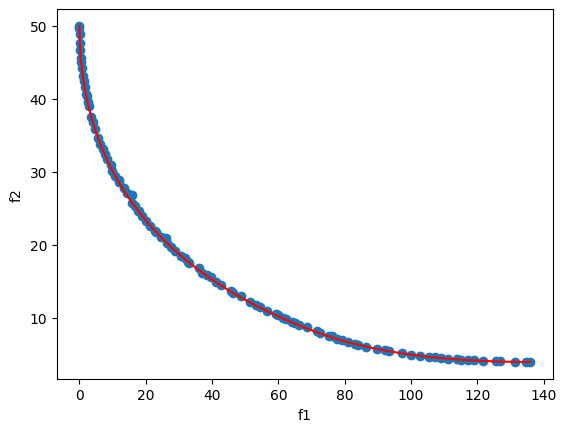

In [54]:
def plot_pareto(plot_optimal: bool = False):
    pareto_df = experimenter.get_gen_df(GENS)
    fig, ax = plt.subplots()
    ax.scatter(pareto_df["f1"], pareto_df["f2"])

    if plot_optimal:
        optimal_actions = experimenter.evaluator.get_optimal()
        optimal_outcomes = experimenter.evaluator.compute_outcomes(experimenter.evaluator.contexts, optimal_actions)
        ax.plot(optimal_outcomes[:, 0], optimal_outcomes[:, 1], "red", label="Optimal pareto")
    
    ax.set_xlabel("f1")
    ax.set_ylabel("f2")

    plt.show()

plot_pareto(True)

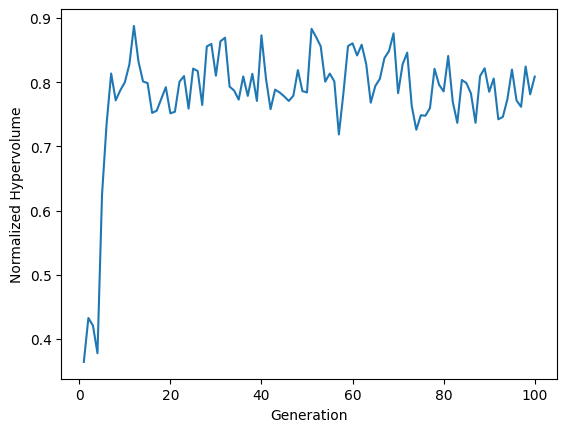

In [55]:
def plot_hypervolume():
    optimal_actions = experimenter.evaluator.get_optimal()
    optimal_outcomes = experimenter.evaluator.compute_outcomes(experimenter.evaluator.contexts, optimal_actions)
    ref_point = torch.max(optimal_outcomes, dim=0).values
    ref_point = ref_point.cpu().numpy()
    ideal = np.array([0, 0])
    optimal_hypervolume = experimenter.compute_hypervolume_2d(optimal_outcomes, ref_point, ideal)

    hypervolumes = []
    for gen in range(1, GENS + 1):
        gens_df = experimenter.get_gen_df(gen)
        pareto_front = gens_df[["f1", "f2"]].values
        hypervolume = experimenter.compute_hypervolume_2d(pareto_front, ref_point, ideal)
        hypervolume /= optimal_hypervolume
        hypervolumes.append(hypervolume)
    
    fig, ax = plt.subplots()
    ax.plot(range(1, GENS + 1), hypervolumes)

    ax.set_xlabel("Generation")
    ax.set_ylabel("Normalized Hypervolume")
    plt.show()

plot_hypervolume()

In [56]:
def plot_solution_space(ax: plt.Axes, context_idx: int, gen: int, color_idx: int, plot_optimal: bool = True):

    pareto_df = experimenter.get_gen_df(gen, pareto=True)

    all_X = []
    for cand_id in pareto_df["cand_id"]:
        # X: N x C
        X = experimenter.get_candidate_solutions(cand_id)
        # all_X: P x C
        all_X.append(X[context_idx])
    all_X = np.stack(all_X)
    x1s = all_X[:, 0]
    x2s = all_X[:, 1]

    label = context_idx
    ax.scatter(x1s, x2s, label=label, color=f"C{color_idx}")

    if plot_optimal:
        optimal = experimenter.evaluator.get_optimal().cpu().numpy()
        ax.plot(optimal[:, 0], optimal[:, 1], color=f"C{color_idx}", linestyle="--")
    return ax

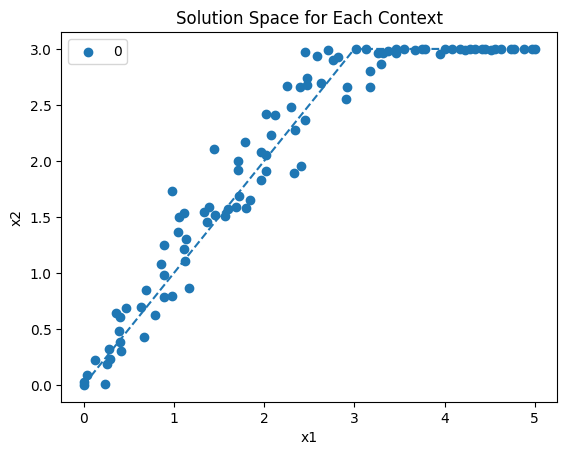

In [57]:
fig, ax = plt.subplots()
ax = plot_solution_space(ax, 0, GENS, 0, True)

ax.legend()
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Solution Space for Each Context")

plt.show()